# Step 3 — Exploratory Data Analysis

**Project:** *Why Do Significant Railway Accident Rates Differ Across Europe? A Fully Bayesian Hierarchical Analysis of Railway Safety*

This notebook performs the complete exploratory data analysis for the dataset:

- 27 countries
- 2010–2024
- 405 country-year observations
- outcome: significant railway accident count
- exposure: train-km

The goal of this step is to understand the observed data and produce evidence that motivates the later modelling progression.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# Paths
# ============================================================

DATA_PATH = (
    "../data/processed/"
    "railway_country_year_2010_2024.csv"
)

FIGURE_DIR = Path("../figures/eda")
TABLE_DIR = Path("../tables/eda")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH)
print("Figure directory:", FIGURE_DIR)
print("Table directory:", TABLE_DIR)


Data path: ../data/processed/railway_country_year_2010_2024.csv
Figure directory: ..\figures\eda
Table directory: ..\tables\eda


## 2. Load and validate the frozen dataset

We first reload the final processed dataset and repeat the key validation checks before performing any analysis.


In [2]:
# ============================================================
# Load the frozen dataset
# ============================================================

data = pd.read_csv(DATA_PATH)

print(data.head())
print("\nShape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())


   year country  accidents  train_km country_name  year_centered  \
0  2010      AT       79.0     156.1      Austria             -7   
1  2011      AT       84.0     152.2      Austria             -6   
2  2012      AT       87.0     149.8      Austria             -5   
3  2013      AT       73.0     150.7      Austria             -4   
4  2014      AT       61.0     152.4      Austria             -3   

   accidents_per_million_train_km  country_id  
0                        0.506086           1  
1                        0.551905           1  
2                        0.580774           1  
3                        0.484406           1  
4                        0.400262           1  

Shape: (405, 8)

Columns:
['year', 'country', 'accidents', 'train_km', 'country_name', 'year_centered', 'accidents_per_million_train_km', 'country_id']


In [3]:
# ============================================================
# Basic validation
# ============================================================

assert len(data) == 405
assert data["country"].nunique() == 27
assert data["year"].nunique() == 15
assert data["year"].min() == 2010
assert data["year"].max() == 2024
assert data.isna().sum().sum() == 0
assert data.duplicated(["country", "year"]).sum() == 0
assert (data["train_km"] > 0).all()
assert (data["accidents"] >= 0).all()

# Accident counts should be integers.
assert ((data["accidents"] % 1) == 0).all()
data["accidents"] = data["accidents"].astype(int)

# Every country must have exactly 15 observations.
assert (
    data.groupby("country")
    .size()
    .eq(15)
    .all()
)

print("Dataset validation passed.")


Dataset validation passed.


## 3. Main descriptive statistics

This section summarizes the size of the dataset, accident counts, railway exposure, and exposure-adjusted accident rates.


In [4]:
# ============================================================
# Main descriptive summary
# ============================================================

summary = pd.DataFrame(
    {
        "Statistic": [
            "Number of observations",
            "Number of countries",
            "Number of years",
            "Total significant accidents",
            "Mean accidents per country-year",
            "Variance of accidents",
            "Median accidents",
            "Minimum accidents",
            "Maximum accidents",
            "Zero-accident observations",
            "Mean train-km",
            "Median train-km",
            "Minimum train-km",
            "Maximum train-km",
            "Mean accident rate",
            "Median accident rate",
        ],
        "Value": [
            len(data),
            data["country"].nunique(),
            data["year"].nunique(),
            data["accidents"].sum(),
            data["accidents"].mean(),
            data["accidents"].var(),
            data["accidents"].median(),
            data["accidents"].min(),
            data["accidents"].max(),
            (data["accidents"] == 0).sum(),
            data["train_km"].mean(),
            data["train_km"].median(),
            data["train_km"].min(),
            data["train_km"].max(),
            data["accidents_per_million_train_km"].mean(),
            data["accidents_per_million_train_km"].median(),
        ],
    }
)

print(summary.to_string(index=False))

summary.to_csv(
    TABLE_DIR / "descriptive_summary.csv",
    index=False,
)


                      Statistic        Value
         Number of observations   405.000000
            Number of countries    27.000000
                Number of years    15.000000
    Total significant accidents 27121.000000
Mean accidents per country-year    66.965432
          Variance of accidents  6579.340386
               Median accidents    36.000000
              Minimum accidents     0.000000
              Maximum accidents   488.000000
     Zero-accident observations     7.000000
                  Mean train-km   143.408786
                Median train-km    62.800000
               Minimum train-km     6.500000
               Maximum train-km  1146.600000
             Mean accident rate     0.777325
           Median accident rate     0.500000


In [5]:
# Compact numerical summary

numeric_summary = data[
    [
        "accidents",
        "train_km",
        "accidents_per_million_train_km",
    ]
].describe()

print(numeric_summary)

numeric_summary.to_csv(
    TABLE_DIR / "numeric_summary.csv"
)


        accidents     train_km  accidents_per_million_train_km
count  405.000000   405.000000                      405.000000
mean    66.965432   143.408786                        0.777325
std     81.113133   214.528516                        0.682682
min      0.000000     6.500000                        0.000000
25%     18.000000    20.500000                        0.267779
50%     36.000000    62.800000                        0.500000
75%     89.000000   164.700000                        1.183432
max    488.000000  1146.600000                        4.000000


## 4. Zero-accident observations

Zero accident counts are valid observations and must not be removed. They are important for later checking how well the candidate count models reproduce the lower tail of the data.


In [6]:
# ============================================================
# Zero-accident observations
# ============================================================

zero_accidents = data.loc[
    data["accidents"] == 0,
    [
        "country_name",
        "year",
        "accidents",
        "train_km",
        "accidents_per_million_train_km",
    ],
].copy()

print(zero_accidents.to_string(index=False))

zero_accidents.to_csv(
    TABLE_DIR / "zero_accident_observations.csv",
    index=False,
)


country_name  year  accidents  train_km  accidents_per_million_train_km
     Ireland  2012          0      18.4                             0.0
     Ireland  2016          0      18.2                             0.0
     Ireland  2020          0      15.6                             0.0
  Luxembourg  2012          0       8.8                             0.0
  Luxembourg  2014          0       9.0                             0.0
  Luxembourg  2015          0       9.2                             0.0
  Luxembourg  2019          0       8.6                             0.0


## 5. Overall European trend

Two summaries are examined:

1. total significant accidents by year;
2. total accidents divided by total train-km for each year.

The aggregate rate is calculated as:

$$
\frac{\sum_i Y_{it}}{\sum_i E_{it}}
$$

rather than as the simple average of country-specific rates.


In [7]:
# ============================================================
# Year-level summary
# ============================================================

yearly = (
    data.groupby("year", as_index=False)
    .agg(
        total_accidents=("accidents", "sum"),
        total_train_km=("train_km", "sum"),
    )
)

yearly[
    "accidents_per_million_train_km"
] = (
    yearly["total_accidents"]
    / yearly["total_train_km"]
)

print(yearly.to_string(index=False))

yearly.to_csv(
    TABLE_DIR / "yearly_summary.csv",
    index=False,
)


 year  total_accidents  total_train_km  accidents_per_million_train_km
 2010             2300       3727.4000                        0.617052
 2011             2224       3789.9000                        0.586823
 2012             2054       3771.5000                        0.544611
 2013             1968       3759.2000                        0.523516
 2014             2105       3777.2000                        0.557291
 2015             1815       3798.6000                        0.477808
 2016             1795       3847.4000                        0.466549
 2017             1841       3912.0000                        0.470603
 2018             1729       3919.5000                        0.441128
 2019             1579       3921.0000                        0.402703
 2020             1392       3584.4000                        0.388350
 2021             1460       3842.8000                        0.379931
 2022             1631       4024.9000                        0.405227
 2023 

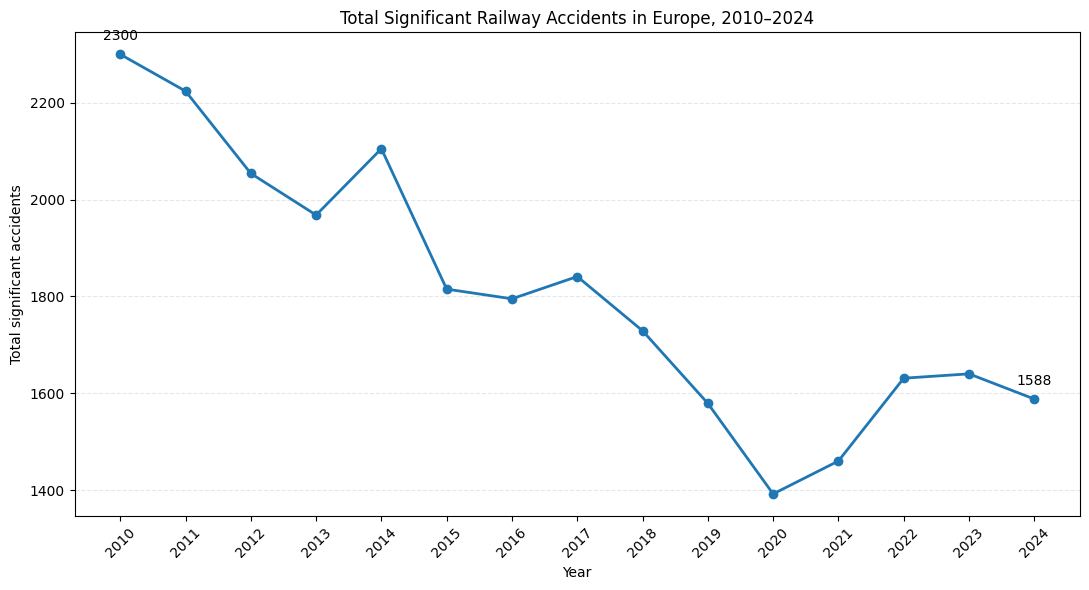

In [22]:
# ============================================================
# Figure 1 — Total significant accidents by year
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    yearly["year"],
    yearly["total_accidents"],
    marker="o",
    linewidth=2,
    markersize=6,
)

ax.set(
    xlabel="Year",
    ylabel="Total significant accidents",
    title="Total Significant Railway Accidents in Europe, 2010–2024",
)

ax.set_xticks(yearly["year"])
ax.tick_params(axis="x", rotation=45)

ax.grid(
    axis="y",
    alpha=0.3,
    linestyle="--",
)

# Label the first and last observations
for index in [0, len(yearly) - 1]:
    row = yearly.iloc[index]

    ax.annotate(
        f"{int(row['total_accidents'])}",
        (
            row["year"],
            row["total_accidents"],
        ),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
    )

fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "01_total_accidents_by_year.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

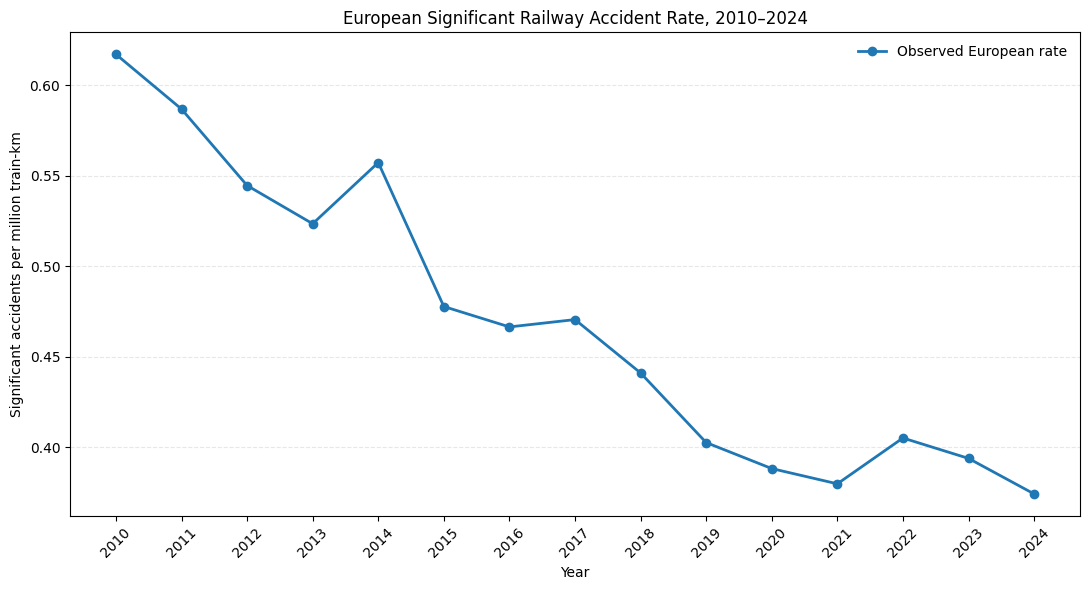

In [23]:
# ============================================================
# Figure 2 — European exposure-adjusted accident rate by year
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    yearly["year"],
    yearly["accidents_per_million_train_km"],
    marker="o",
    linewidth=2,
    markersize=6,
    label="Observed European rate",
)

ax.set(
    xlabel="Year",
    ylabel="Significant accidents per million train-km",
    title="European Significant Railway Accident Rate, 2010–2024",
)

ax.set_xticks(yearly["year"])
ax.tick_params(axis="x", rotation=45)

ax.grid(
    axis="y",
    alpha=0.3,
    linestyle="--",
)

ax.legend(
    frameon=False,
    loc="best",
)

fig.tight_layout()

fig.savefig(
    FIGURE_DIR
    / "02_european_accident_rate_by_year.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 6. Distribution of accident counts

The count distribution is inspected for skewness, zero counts, and unusually large observations.


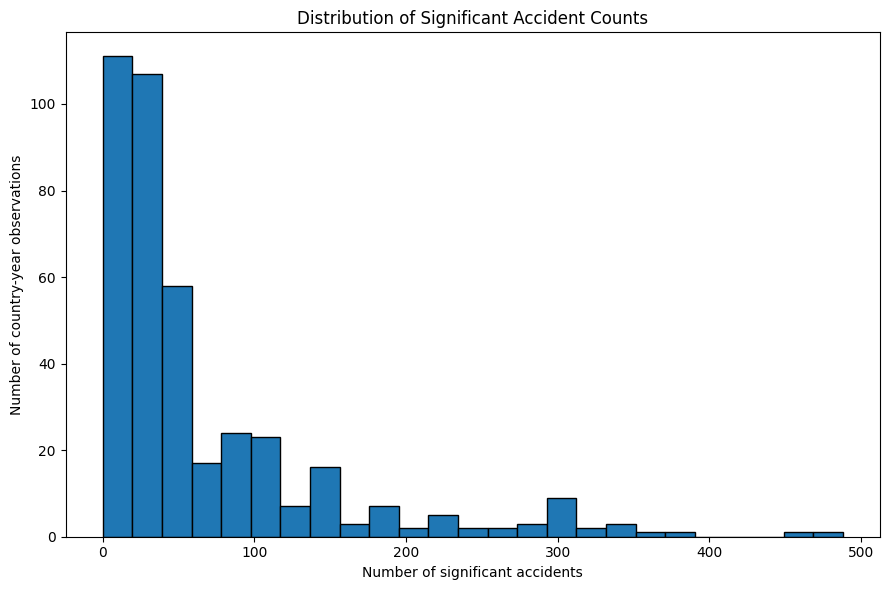

In [10]:
# ============================================================
# Figure 3 — Distribution of significant accident counts
# ============================================================

plt.figure(figsize=(9, 6))

plt.hist(
    data["accidents"],
    bins=25,
    edgecolor="black",
)

plt.xlabel("Number of significant accidents")
plt.ylabel("Number of country-year observations")
plt.title(
    "Distribution of Significant Accident Counts"
)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "03_distribution_accident_counts.png",
    dpi=300,
)

plt.show()


## 7. Distribution of exposure-adjusted accident rates

This helps distinguish countries with large raw accident counts because of high railway activity from countries with genuinely higher observed accident rates.


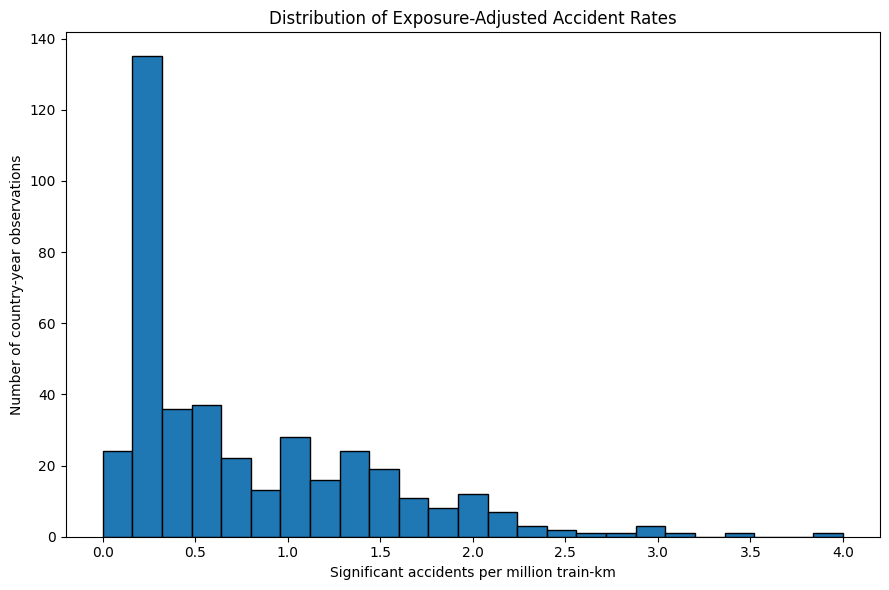

In [11]:
# ============================================================
# Figure 4 — Distribution of exposure-adjusted accident rates
# ============================================================

plt.figure(figsize=(9, 6))

plt.hist(
    data["accidents_per_million_train_km"],
    bins=25,
    edgecolor="black",
)

plt.xlabel(
    "Significant accidents per million train-km"
)
plt.ylabel("Number of country-year observations")
plt.title(
    "Distribution of Exposure-Adjusted Accident Rates"
)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "04_distribution_accident_rates.png",
    dpi=300,
)

plt.show()


## 8. Country-specific trajectories

Persistent differences between country trajectories would provide descriptive motivation for the later hierarchical country effect.


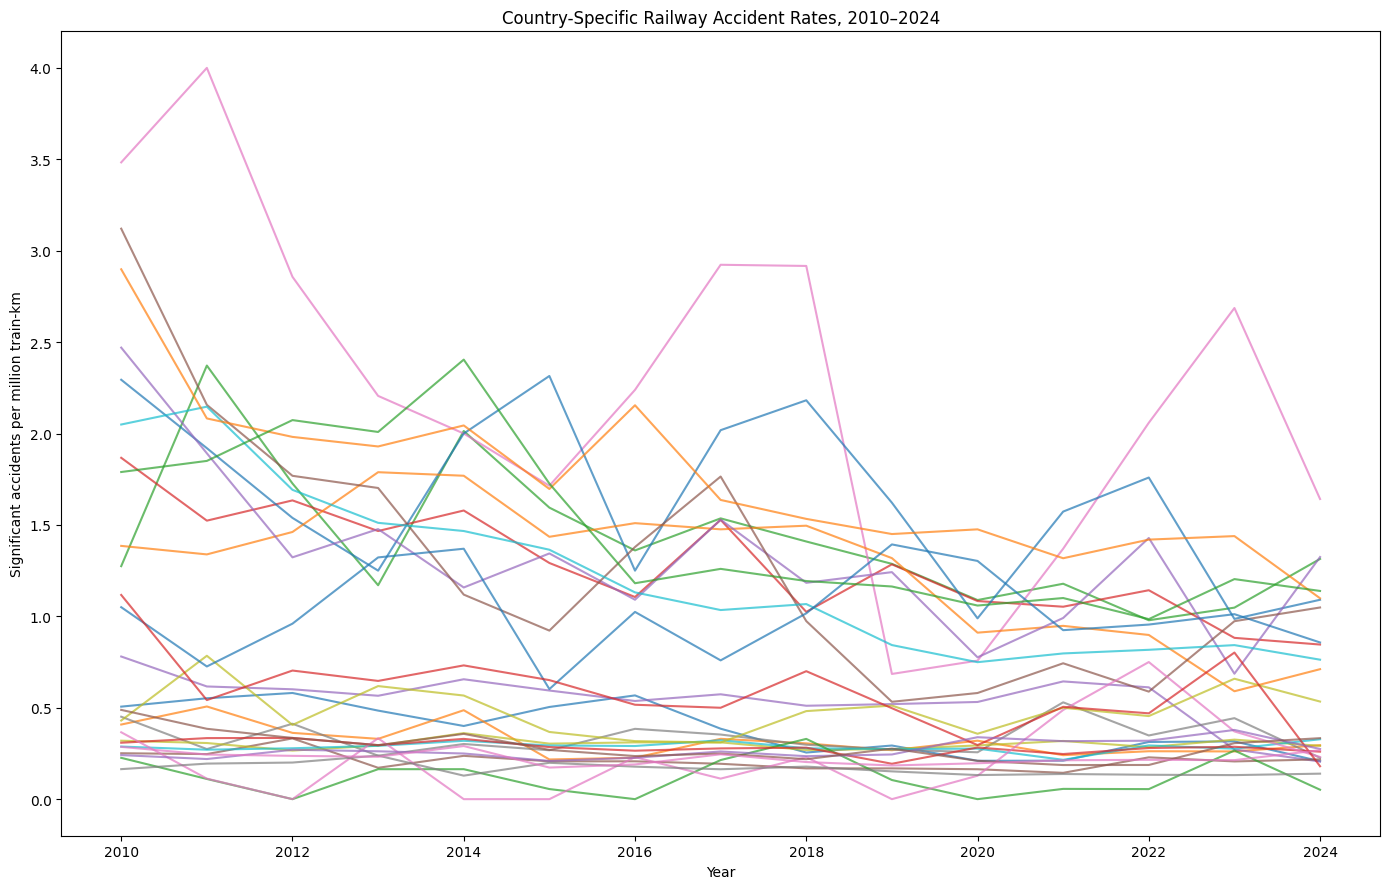

In [12]:
# ============================================================
# Figure 5 — Country-specific accident-rate trajectories
# ============================================================

plt.figure(figsize=(14, 9))

for country_name, group in data.groupby(
    "country_name"
):
    group = group.sort_values("year")

    plt.plot(
        group["year"],
        group["accidents_per_million_train_km"],
        alpha=0.7,
    )

plt.xlabel("Year")
plt.ylabel(
    "Significant accidents per million train-km"
)
plt.title(
    "Country-Specific Railway Accident Rates, "
    "2010–2024"
)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "05_country_rate_trajectories.png",
    dpi=300,
)

plt.show()


## 9. Country-level summaries

Country-level rates are calculated using total accidents divided by total exposure over the full study period.

These are descriptive observed rates only. They should not be interpreted as final adjusted safety rankings because the later hierarchical model will provide partially pooled country effects.


In [13]:
# ============================================================
# Country-level summary
# ============================================================

country_summary = (
    data.groupby(
        ["country", "country_name"],
        as_index=False,
    )
    .agg(
        total_accidents=("accidents", "sum"),
        mean_accidents=("accidents", "mean"),
        total_train_km=("train_km", "sum"),
    )
)

country_summary[
    "overall_accident_rate"
] = (
    country_summary["total_accidents"]
    / country_summary["total_train_km"]
)

country_summary = (
    country_summary
    .sort_values(
        "overall_accident_rate",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(country_summary.to_string(index=False))

country_summary.to_csv(
    TABLE_DIR / "country_summary.csv",
    index=False,
)


country country_name  total_accidents  mean_accidents  total_train_km  overall_accident_rate
     EE      Estonia              239       15.933333      106.000000               2.254717
     RO      Romania             2319      154.600000     1308.607000               1.772113
     EL       Greece              278       18.533333      162.252000               1.713384
     SK     Slovakia             1095       73.000000      752.258000               1.455618
     BG     Bulgaria              644       42.933333      453.900000               1.418815
     LV       Latvia              312       20.800000      228.270000               1.366802
     HR      Croatia              431       28.733333      331.000000               1.302115
     LT    Lithuania              276       18.400000      212.692000               1.297651
     HU      Hungary             2054      136.933333     1633.668000               1.257293
     PL       Poland             4336      289.066667     3656.681000 

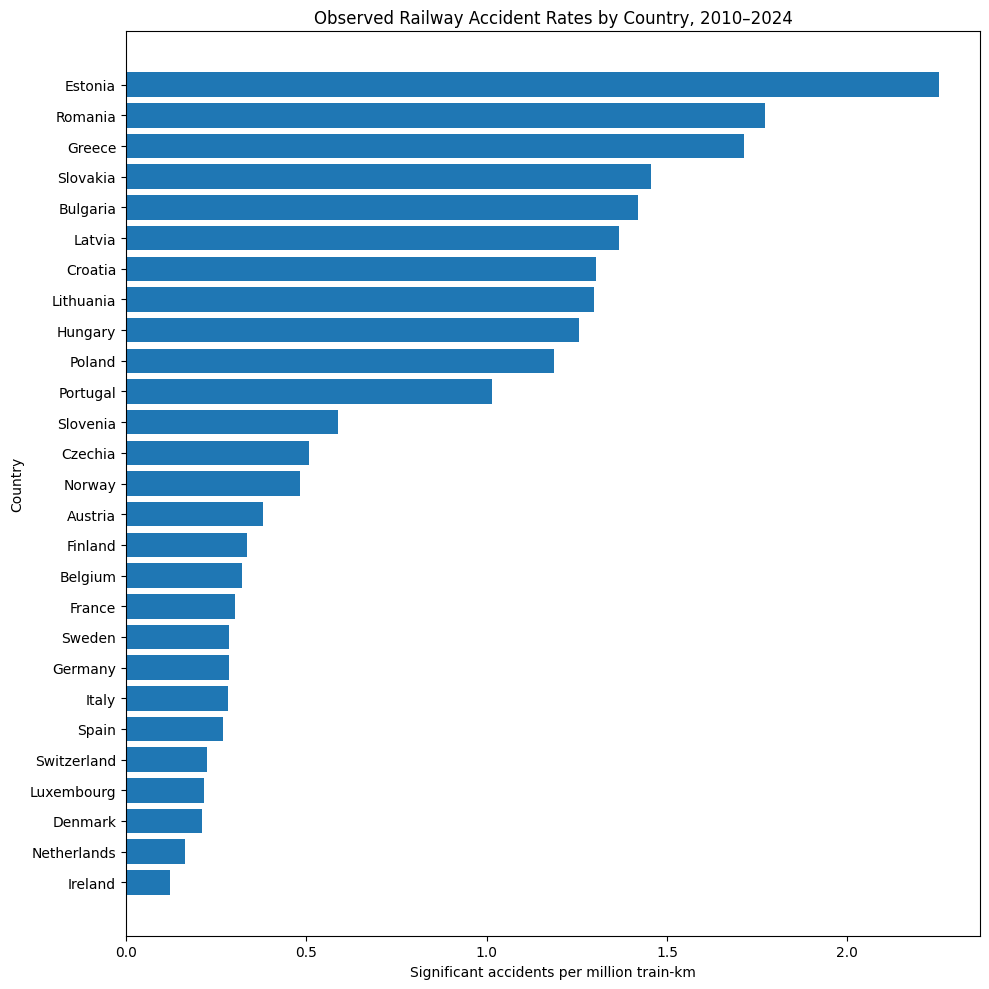

In [14]:
# ============================================================
# Figure 6 — Overall observed accident rates by country
# ============================================================

plot_data = country_summary.sort_values(
    "overall_accident_rate"
)

plt.figure(figsize=(10, 10))

plt.barh(
    plot_data["country_name"],
    plot_data["overall_accident_rate"],
)

plt.xlabel(
    "Significant accidents per million train-km"
)
plt.ylabel("Country")
plt.title(
    "Observed Railway Accident Rates by Country, "
    "2010–2024"
)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "06_country_overall_accident_rates.png",
    dpi=300,
)

plt.show()


## 10. Descriptive investigation of overdispersion

For a simple homogeneous Poisson distribution:

$$
\operatorname{Var}(Y)=\operatorname{E}(Y).
$$

A variance-to-mean ratio much larger than 1 is descriptive evidence of substantial heterogeneity.

However, the raw accident counts also vary because countries have very different railway exposure. Therefore, this calculation alone does **not** prove that the exposure-adjusted Poisson regression is inadequate. Formal assessment will later come from model comparison and posterior predictive checks.


In [15]:
# ============================================================
# Raw variance-to-mean comparison
# ============================================================

mean_accidents = data["accidents"].mean()
variance_accidents = data["accidents"].var()

variance_mean_ratio = (
    variance_accidents / mean_accidents
)

print(
    f"Mean accident count: "
    f"{mean_accidents:.4f}"
)

print(
    f"Variance of accident count: "
    f"{variance_accidents:.4f}"
)

print(
    f"Variance / mean ratio: "
    f"{variance_mean_ratio:.4f}"
)


Mean accident count: 66.9654
Variance of accident count: 6579.3404
Variance / mean ratio: 98.2498


## 11. Relationship between railway exposure and accident counts

This figure illustrates why train-km must be included as an exposure term in the statistical models.


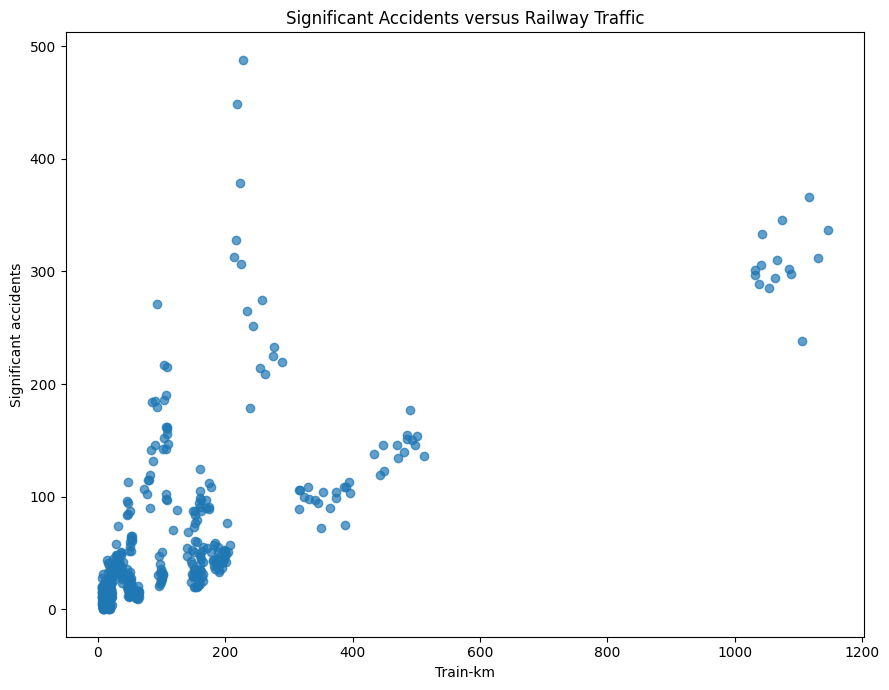

In [16]:
# ============================================================
# Figure 7 — Significant accidents versus railway traffic
# ============================================================

plt.figure(figsize=(9, 7))

plt.scatter(
    data["train_km"],
    data["accidents"],
    alpha=0.7,
)

plt.xlabel("Train-km")
plt.ylabel("Significant accidents")
plt.title(
    "Significant Accidents versus Railway Traffic"
)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "07_accidents_vs_train_km.png",
    dpi=300,
)

plt.show()


## 12. Identify unusual country-year observations

The largest raw accident counts and the highest exposure-adjusted rates are inspected separately.

No observations are removed automatically at this stage.


In [17]:
# ============================================================
# Largest raw accident counts
# ============================================================

largest_counts = (
    data[
        [
            "country_name",
            "year",
            "accidents",
            "train_km",
            "accidents_per_million_train_km",
        ]
    ]
    .sort_values(
        "accidents",
        ascending=False,
    )
    .head(10)
)

print("Largest accident counts:")
print(largest_counts.to_string(index=False))

largest_counts.to_csv(
    TABLE_DIR / "largest_accident_counts.csv",
    index=False,
)


Largest accident counts:
country_name  year  accidents  train_km  accidents_per_million_train_km
      Poland  2011        488     227.3                        2.146942
      Poland  2010        449     219.1                        2.049293
      Poland  2012        379     224.0                        1.691964
     Germany  2024        366    1117.0                        0.327663
     Germany  2017        346    1073.5                        0.322310
     Germany  2022        337    1146.6                        0.293912
     Germany  2014        333    1043.2                        0.319210
      Poland  2013        328     217.0                        1.511521
      Poland  2014        313     213.4                        1.466729
     Germany  2023        312    1130.8                        0.275911


In [18]:
# ============================================================
# Highest exposure-adjusted accident rates
# ============================================================

largest_rates = (
    data[
        [
            "country_name",
            "year",
            "accidents",
            "train_km",
            "accidents_per_million_train_km",
        ]
    ]
    .sort_values(
        "accidents_per_million_train_km",
        ascending=False,
    )
    .head(10)
)

print("Highest accident rates:")
print(largest_rates.to_string(index=False))

largest_rates.to_csv(
    TABLE_DIR / "largest_accident_rates.csv",
    index=False,
)


Highest accident rates:
country_name  year  accidents  train_km  accidents_per_million_train_km
     Estonia  2011         28       7.0                        4.000000
     Estonia  2010         31       8.9                        3.483146
   Lithuania  2010         44      14.1                        3.120567
     Estonia  2017         19       6.5                        2.923077
     Estonia  2018         21       7.2                        2.916667
     Romania  2010        271      93.5                        2.898396
     Estonia  2012         20       7.0                        2.857143
     Estonia  2023         18       6.7                        2.686567
      Latvia  2010         41      16.6                        2.469880
    Slovakia  2014        113      47.0                        2.404255


## 13. Final EDA summary

The printed output below provides the key numerical values that should be retained for interpretation and later report writing.


In [19]:
# ============================================================
# Final EDA summary
# ============================================================

print("=" * 60)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 60)

print(
    f"Observations: "
    f"{len(data)}"
)

print(
    f"Countries: "
    f"{data['country'].nunique()}"
)

print(
    f"Years: "
    f"{data['year'].min()}-"
    f"{data['year'].max()}"
)

print(
    f"Total significant accidents: "
    f"{data['accidents'].sum()}"
)

print(
    f"Mean accident count: "
    f"{data['accidents'].mean():.2f}"
)

print(
    f"Variance of accident counts: "
    f"{data['accidents'].var():.2f}"
)

print(
    f"Variance/mean ratio: "
    f"{variance_mean_ratio:.2f}"
)

print(
    f"Zero-accident observations: "
    f"{(data['accidents'] == 0).sum()}"
)

print(
    f"Minimum accident count: "
    f"{data['accidents'].min()}"
)

print(
    f"Maximum accident count: "
    f"{data['accidents'].max()}"
)

print("\nEDA completed successfully.")


EXPLORATORY DATA ANALYSIS SUMMARY
Observations: 405
Countries: 27
Years: 2010-2024
Total significant accidents: 27121
Mean accident count: 66.97
Variance of accident counts: 6579.34
Variance/mean ratio: 98.25
Zero-accident observations: 7
Minimum accident count: 0
Maximum accident count: 488

EDA completed successfully.


# Interpretation checklist before moving to Step 4

1. **Time trend:** Is there a visible upward or downward trend in the exposure-adjusted European accident rate?
2. **Country heterogeneity:** Do countries appear to have persistently different accident-rate levels?
3. **Count variability:** How large is the raw variance relative to the mean?
4. **Unusual observations:** Are there countries or country-years with exceptionally high counts or rates?
